# KNN (K-Nearest Neighbors)
K개의 가장 가까운 이웃 데이터를 기반으로 새로운 데이터를 분류하거나 예측하는 알고리즘

KNN은 학습 단계가 없어 Lazy Learning이라 하며 간단하지만 예측이 느리다는 단점이 있다.

- 분류 : K개의 이웃 중 다수결로 클래스를 결정
- 회귀 : K개의 이웃의 평균값으로 예측

## 새로운 데이터가 들어오면

1. 새로운 데이터와 기존 데이터와의 거리를 유클리드 거리로 계산한다. $$distance = \sqrt{(\hat{x} - x)^{2} + (\hat{y} - y)^{2}}$$

2. 거리가 가까운 K개의 데이터를 뽑는다.


3. 분류라면 다수결로 새로운 데이터의 클래스를 분류하고 회귀라면 평균을 낸다.

## 데이터 생성

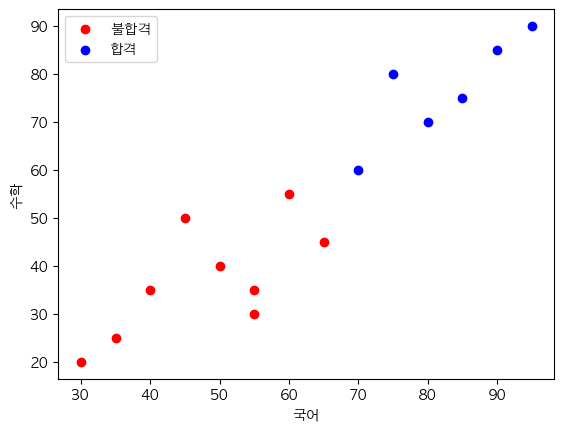

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

data = {
    "국어": [30, 40, 45, 50, 55, 60, 35, 70, 75, 80, 85, 90, 65, 95, 55],
    "수학": [20, 35, 50, 40, 30, 55, 25, 60, 80, 70, 75, 85, 45, 90, 35],
    "합격여부": [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    "공부시간" : [0.5, 0.6, 0.8, 1.3, 0.2, 0.7, 0.9, 0.5, 2.7, 3.5, 4.0, 3.2, 2.2, 4.3, 1.2]
}

df = pd.DataFrame(data)

plt.scatter(df[df["합격여부"]==0]["국어"], df[df["합격여부"]==0]["수학"], label="불합격", color="red")
plt.scatter(df[df["합격여부"]==1]["국어"], df[df["합격여부"]==1]["수학"], label="합격", color="blue")
plt.xlabel("국어")
plt.ylabel("수학")
plt.legend()
plt.show()

## KNN 분류 구현하기

In [17]:
def knn_classification(k, score):
    distances = []

    for i in range(len(df)):
        distance = np.sqrt((float(df.iloc[i]["국어"] - score[0]) ** 2) + (float(df.iloc[i]["수학"] - score[1]) ** 2))
        distances.append((distance, df.iloc[i]["합격여부"]))

    distances.sort()

    neighbors = distances[:k]
    result = np.sum([n[1] for n in neighbors])

    return 1 if result > k/2 else 0

pred1 = knn_classification(3, [90, 90])
pred2 = knn_classification(3, [20, 20])

print(pred1)
print(pred2)


1
0


## KNN 회귀 구현하기

In [ ]:
def knn_regression(k, score):
    distances = []
    n = len(df)

    for i in range(n):
        distance = np.sqrt((df.iloc[i]["국어"] - score[0]) ** 2 + (df.iloc[i]["수학"] - score[1]) ** 2)
        distances.append((distance, df.iloc[i]["공부시간"]))

    distances.sort()
    neighbor = distances[:k]

    result = np.mean([n[1] for n in neighbor])

    return result

pred1 = knn_regression(3, [90, 90])
pred2 = knn_regression(3, [20, 20])

print(pred1)
print(pred2)

3.8333333333333335
0.6666666666666666


## Sklearn으로 구현하기

In [20]:
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier

In [22]:
data = load_iris()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size= 0.7)

In [ ]:
model = KNeighborsClassifier(n_neighbors= 3)

# 학습을 안하는데 왜 fit을 할까? -> 전통적인 방식을 따르는 것일뿐. 학습은 하지 않고 저장만 된다.
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(accuracy_score(y_test, y_pred))

0.9777777777777777
